<a href="https://colab.research.google.com/github/Sneha17A/Learning_ML/blob/main/DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
keras.utils.set_random_seed(42)

In [ ]:
df = pd.read_csv("http://storage.googleapis.com/download.tensorflow.org/data/heart.csv")

In [ ]:
df.shape

(303, 14)

In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0


In [ ]:
df.target.value_counts(normalize= True, dropna = False)

,proportion
target,
0,0.726073
1,0.273927


In [ ]:
categorical_varibles = ['sex','cp','fbs','restecg','exang','ca','thal']
numerics = ['age','trestbps','chol','thalach','oldpeak','slope']

In [ ]:
df = pd.get_dummies(df,columns= categorical_varibles)

In [ ]:
df.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,63,145,233,150,2.3,3,0,False,True,False,...,False,True,False,False,False,False,False,True,False,False
1,67,160,286,108,1.5,2,1,False,True,False,...,True,False,False,False,True,False,False,False,True,False
2,67,120,229,129,2.6,2,0,False,True,False,...,True,False,False,True,False,False,False,False,False,True
3,37,130,250,187,3.5,3,0,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,41,130,204,172,1.4,1,0,True,False,False,...,False,True,False,False,False,False,False,False,True,False


In [ ]:
test_df = df.sample(frac= 0.2,random_state= 42)
train_df = df.drop(test_df.index)

In [ ]:
train_df.shape

(242, 30)

In [ ]:
test_df.shape

(61, 30)

In [ ]:
means = train_df[numerics].mean()
sd = train_df[numerics].std()

In [ ]:
means

,0
age,54.268595
trestbps,131.995868
chol,246.512397
thalach,149.805785
oldpeak,1.032645
slope,1.590909


In [ ]:
train_df[numerics] = (train_df[numerics] - means)/sd
test_df[numerics] = (test_df[numerics] - means)/sd

In [ ]:
train_df.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,-5.883628,-7.287818,-5.090011,-6.475681,0.043443,1.004932,0,False,True,False,...,False,True,False,False,False,False,False,True,False,False
1,-5.834895,-7.241588,-5.067465,-6.554171,-0.541239,-1.492477,1,False,True,False,...,True,False,False,False,True,False,False,False,True,False
2,-5.834895,-7.364869,-5.091712,-6.514926,0.262698,-1.492477,0,False,True,False,...,True,False,False,True,False,False,False,False,False,True
3,-6.200388,-7.334049,-5.082779,-6.406536,0.920465,1.004932,0,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,-6.151655,-7.334049,-5.102347,-6.434568,-0.614324,-3.989886,0,True,False,False,...,False,True,False,False,False,False,False,False,True,False


In [ ]:
train = train_df.to_numpy()
test = test_df.to_numpy()

In [ ]:
train_X = np.delete(train,6,axis =1)
test_X = np.delete(test,6,axis=1)

In [ ]:
train_X.shape, test_X.shape

((242, 29), (61, 29))

In [ ]:
train_y = train[:,6]
test_y = test[:,6]

In [ ]:
train_y.shape, test_y.shape

((242,), (61,))

In [ ]:
num_columns = train_X.shape[1]
input = keras.Input(shape = (num_columns,))
h = keras.layers.Dense(16,activation = 'relu', name = "hidden")(input)
output = keras.layers.Dense(1,activation = 'sigmoid', name = "output")(h)
model = keras.Model(inputs = input, outputs = output)

In [ ]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 29)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ (None, 16)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 497 (1.94 KB)

 Trainable params: 497 (1.94 KB)

 Non-trainable params: 0 (0.00 B)

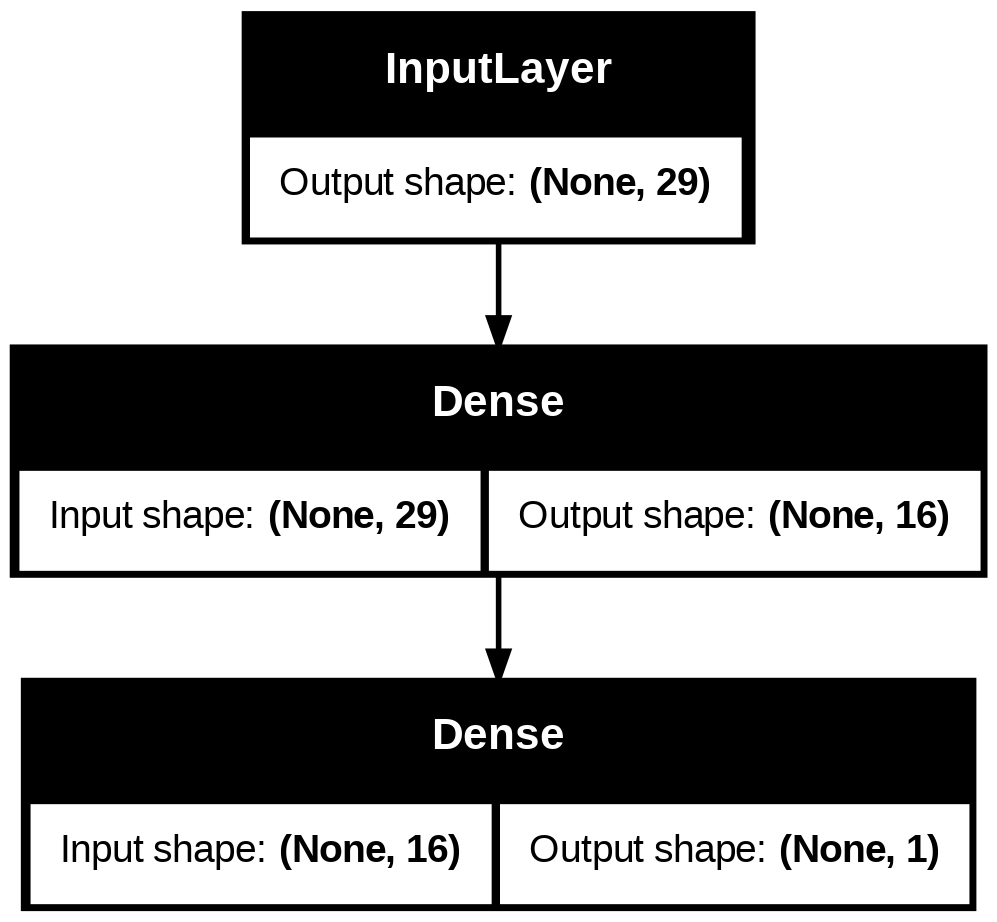

In [ ]:
keras.utils.plot_model(model,show_shapes = True)

In [ ]:
from types import MethodDescriptorType
model.compile(optimizer="adam",
              loss = "binary_crossentropy",
              metrics = ["accuracy"])

In [ ]:
history = model.fit(train_X.astype(np.float32),
                    train_y.astype(np.float32),
                    epochs=100,
                    batch_size=32,
                    verbose=1,
                    validation_split=0.2)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0136 - val_accuracy: 0.7551 - val_loss: 7.7868
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0136 - val_accuracy: 0.7551 - val_loss: 7.7947
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0135 - val_accuracy: 0.7551 - val_loss: 7.8018
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0134 - val_accuracy: 0.7551 - val_loss: 7.8094
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0133 - val_accuracy: 0.7551 - val_loss: 7.8174
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0133 - val_accuracy: 0.7551 - val_loss: 7.8250
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0132 - val_accuracy: 0.7551 - val_loss: 7.8324
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0131 - val_accuracy: 0.7551 - val_loss:

In [ ]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

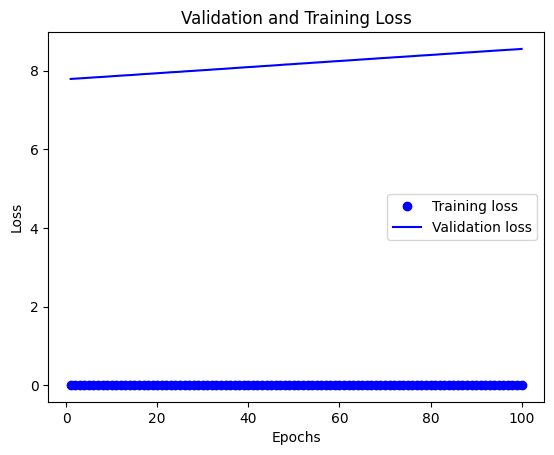

In [ ]:
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1,len(loss_values) + 1)
plt.plot(epochs,loss_values,"bo",label="Training loss")
plt.plot(epochs,val_loss_values,"b",label="Validation loss")
plt.title("Validation and Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

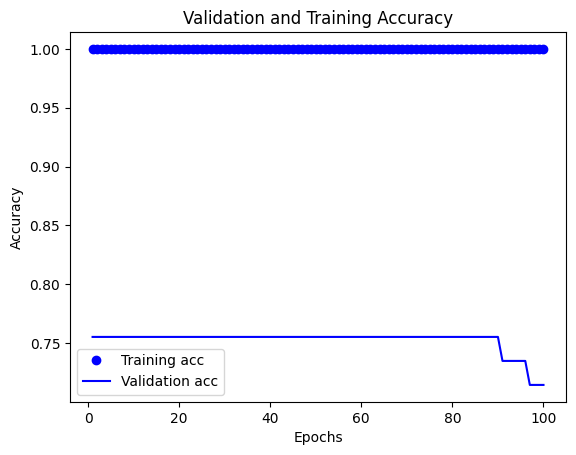

In [ ]:
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs,acc,"bo",label="Training acc")
plt.plot(epochs,val_acc,"b",label="Validation acc")
plt.title("Validation and Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt

In [ ]:
model.evaluate(test_X.astype(np.float32), test_y.astype(np.float32))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8033 - loss: 0.9294


[0.9294074177742004, 0.8032786846160889]


Above represents "Validation loss increased while training loss decreased, indicating overfitting. I addressed this using scaling, dropout, and early stopping."


In [ ]:
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Normalization
import numpy as np

# -----------------------------
# Normalize Data
# -----------------------------

normalizer = Normalization()

normalizer.adapt(train_X)

# -----------------------------
# Build Model
# -----------------------------

model = models.Sequential([

    # Normalization Layer
    normalizer,

    # Hidden Layer 1
    layers.Dense(16, activation='relu'),

    # Dropout
    layers.Dropout(0.5),

    # Hidden Layer 2
    layers.Dense(16, activation='relu'),

    # Dropout
    layers.Dropout(0.5),

    # Output Layer
    layers.Dense(1, activation='sigmoid')

])

# -----------------------------
# Compile Model
# -----------------------------

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# Early Stopping
# -----------------------------

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# -----------------------------
# Train Model
# -----------------------------

history = model.fit(
    train_X.astype(np.float32),
    train_y.astype(np.float32),
    epochs=300,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# -----------------------------
# Evaluate
# -----------------------------

results = model.evaluate(
    test_X.astype(np.float32),
    test_y.astype(np.float32)
)

print(results)

Epoch 1/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.5337 - loss: 0.8392 - val_accuracy: 0.4286 - val_loss: 0.8155
Epoch 2/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4041 - loss: 0.9565 - val_accuracy: 0.4490 - val_loss: 0.7829
Epoch 3/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5440 - loss: 0.8079 - val_accuracy: 0.5306 - val_loss: 0.7531
Epoch 4/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5959 - loss: 0.7466 - val_accuracy: 0.5714 - val_loss: 0.7283
Epoch 5/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5440 - loss: 0.7936 - val_accuracy: 0.5918 - val_loss: 0.7078
Epoch 6/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5233 - loss: 0.8014 - val_accuracy: 0.5918 - val_loss: 0.6892
Epoch 7/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6166 - loss: 0.7174 - val_accuracy: 0.5918 - val_loss: 0.6750
Epoch 8/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6114 - loss: 0.7183 - val_accuracy: 0.5918 - val_loss:

In [ ]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

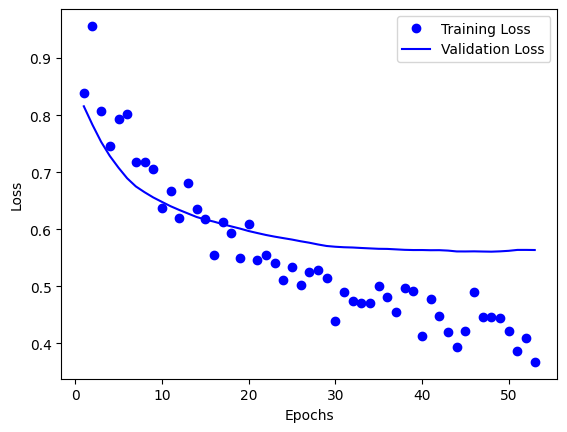

In [ ]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
model.evaluate(test_X.astype(np.float32), test_y.astype(np.float32))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7705 - loss: 0.4145


[0.4145283102989197, 0.7704917788505554]